# Towards energy and material transition integration - a systematic multi-scale modeling and optimization framework.


__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


$\textbf{Import modules}$

In [1]:
import pandas
from numpy import poly1d, polyfit
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt
from itertools import product

**Import solar dni and wind speeds for Harris county**


In [2]:
weather20_df = pandas.read_csv('data/ho_solar20.csv', index_col=0)
weather20_df.index = [i.split('+')[0] for i in weather20_df.index]
weather19_df = pandas.read_csv('data/ho_solar19.csv', index_col=0)
weather18_df = pandas.read_csv('data/ho_solar18.csv', names = ['wind_speed', 'dni'])
weather17_df = pandas.read_csv('data/ho_solar17.csv', index_col=0)
weather16_df = pandas.read_csv('data/ho_solar16.csv', index_col=0)
weather15_df = pandas.read_csv('data/ho_solar15.csv', index_col=0)
weather_df_wl = pandas.concat([weather16_df, weather17_df, weather18_df, weather19_df, weather20_df])
weather_df = weather_df_wl[~weather_df_wl.index.str.contains('02-29')] #remove leap years

In [3]:
ho_solar_df = weather_df['dni']
ho_wind_df = weather_df['wind_speed']

<AxesSubplot:>

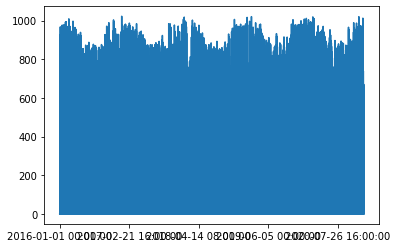

In [4]:
ho_solar_df.plot()

**Demand data from ERCOT**

In [5]:
ercot20 = pandas.read_excel('data/Native_Load_2020.xlsx')
ercot19 = pandas.read_excel('data/Native_Load_2019.xlsx')
ercot18 = pandas.read_excel('data/Native_Load_2018.xlsx')
ercot17 = pandas.read_excel('data/Native_Load_2017.xlsx')
ercot16 = pandas.read_excel('data/Native_Load_2016.xlsx')
ercot = pandas.DataFrame(pandas.concat([ercot16['COAST'], ercot17['COAST'], ercot18['COAST'], ercot19['COAST'], ercot20['COAST']]))
ercot['index'] = weather_df_wl.index
# ercot = ercot.drop(columns= 'HourEnding')
ercot = ercot.set_index('index')
# ercot = ercot[['COAST']]
ercot = ercot[~ercot.index.str.contains('02-29')]
ercot.loc['2016-11-06 23:00:00'] = ercot.loc['2016-11-06 22:00:00'] #random missing data which gave a fucking

**Import natural gas prices from Henry Hub Price Index**  

In [6]:
ercot.iloc[58*24]

COAST    8263.501041
Name: 2016-02-28 00:00:00, dtype: float64

In [7]:
ng_price20 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2020, stretch=True)
ng_price19 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2019, stretch=True)
ng_price18 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2018, stretch=True)
ng_price17 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2017, stretch=True)
ng_price16 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2016, stretch=True)
ng_price_df = pandas.concat([ng_price16, ng_price17, ng_price18, ng_price19, ng_price20])
ng_price_df['index'] = ho_solar_df.index
ng_price_df = ng_price_df.drop(columns= 'scales')
ng_price_df = ng_price_df.set_index('index')


<AxesSubplot:xlabel='index'>

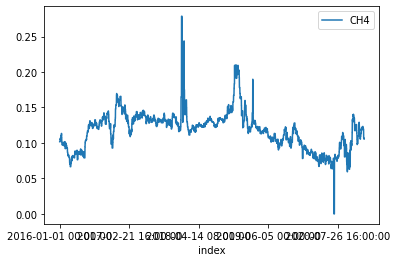

In [8]:
ng_price_df.plot()

**import cost data**


In [9]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

$\textbf{Define temporal scale}$


In [10]:
scales = Temporal_scale(discretization_list=[5, 365, 24], start_zero= 2016)

In [11]:
len(scales.scale[2])

24

In [12]:
scales.__dict__.keys()

dict_keys(['discretization_list', 'start_zero', 'scale', 'list', 'name', 'scale_levels'])

$\textbf{Declare constants for ease}$


In [13]:
bigM = 10**4  # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0

$\textbf{Declare resources}$

In [14]:
Charge = Resource(name='Charge', sell=False,
                  store_max=100, basis='MW', label='Battery energy', block='energystorage')

Air_C = Resource(name='Air_C', store_max=bigM, basis='MW',
                 label='CAES energy', block='energystorage')

H2O_E = Resource(name='H2O_E', store_max=bigM, basis='MW',
                 label='PSH energy', block='energystorage')

Uranium = Resource(name='Uranium', cons_max=(1/4.17*10**(-5))*bigM,
                   price=ur_price/(250/2), basis='kg', label='Uranium', block='energyfeedstock')

Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')

Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')

H2_L = Resource(name='H2_L', store_max=10**10, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')

H2_C = Resource(name='H2_C', store_max= 10**10, loss=0.025/24, revenue=2, mile=1/(0.1180535*1.60934), \
    basis='kg', label='Hydrogen - Local Cryo', block='resourcestorage')


# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource')


H2O = Resource(name='H2O', cons_max=10**10,
               price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
            
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')


CH4 = Resource(name='CH4', cons_max=10 **
               10, price=0.113891, basis='kg', label='Natural gas', block='materialfeedstock')

CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')


CO2_DAC = Resource(
    name='CO2_DAC', basis='kg', label='Carbon dioxide - captured', block='carbonsequestration')

CO2_AQoff = Resource(
    name='CO2_AQoff', store_max=10**6, basis='kg', label='Carbon dioxide - sequestered', block='carbonsequestration')

CO2_EOR = Resource(
    name='CO2_EOR', store_max=10**6, basis='kg', label='Carbon dioxide - EOR', block='carbonsequestration')


CH3OH = Resource(name='CH3OH', sell=True, revenue=0.5,
                 mile=1/(0.0195508*1.60934), basis='kg', label='Methanol', block='resourcedischarge')

CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')

# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')

Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')

Mile = Resource(name = 'Mile', basis = 'miles', sell = True, demand  = True, label = 'miles driven')


$\textbf{Declare Materials}$


In [15]:
LiR = Material(name='LiR', gwp=1.484, H2O=2273, basis= 'kg', label='Rock-based Lithium', citation= 'Nelson Bunyui Manjong (2021), https://www.tcc.fl.edu/media/divisions/academic-affairs/academic-enrichment/urc/poster-abstracts/Xanders_Madison_Poster_URS.pdf') #gwp=(0.216,0.314)
LiB = Material(name='LiB', gwp=0.031, basis= 'kg', label='Brine-based Lithium', citation= 'Nelson Bunyui Manjong (2021)') #gwp=(0.289,0.499)
Mn = Material(name='Mn', gwp=4.51, basis= 'kg', label='Manganese', citation= 'Nelson Bunyui Manjong (2021)') #inventory data #9.6, 2.6,7.9
Ni = Material(name='Ni', gwp=7.64, H2O=80, basis= 'kg', label='Nickel', citation= 'Mark Mistry (2016), Sustainable water use in minerals and metal production')
Co = Material(name='Co', gwp=11.73, basis= 'kg', label='Cobalt', citation= 'Farjana et al. 2019a, b')
Steel = Material(name='Steel', gwp=(0.8,1.4), H2O=3.94, basis= 'kg', label='Steel', citation= 'Kim R.Bawden (2016), Anlong Li (2020)')
CuP = Material(name='Cu', gwp=2.5, H2O=30, basis= 'kg', label='Copper Pyro', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
CuH = Material(name='Cu', gwp=6, H2O=40, basis= 'kg', label='Copper Hyro', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
PbB = Material(name='PbB', gwp=1.5, H2O=15, basis= 'kg', label='Lead BF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
PbI = Material(name='PbI', gwp=2.5, H2O=25, basis= 'kg', label='Lead ISF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
ZnE = Material(name='ZnE', gwp=5, H2O=30, basis= 'kg', label='Zn Elec', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
ZnI = Material(name='ZnI', gwp=3.5, H2O=25, basis= 'kg', label='Zn ISF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
Pd = Material(name='Pd', gwp=3880, H2O=210713, basis= 'kg', label='Palladium', citation= 'Philip Nuss (2014), Simon Meißner (2021)')
Rd = Material(name='Rd', gwp=35100, basis= 'kg', label='Rhodium', citation= 'Philip Nuss (2014)')
Pt = Material(name='Pd', gwp=12500, H2O=31349, basis= 'kg', label='Platinum', citation= 'Philip Nuss (2014), Simon Meißner (2021)')
Y = Material(name='Y', gwp=15.1, basis= 'kg', label='Yttrium', citation= 'Philip Nuss (2014)')
Al = Material(name='Al', gwp=8.2, H2O=147, basis= 'kg', label='Aluminium', citation= 'Philip Nuss (2014), Water requirements of the aluminum industry Water Supply Paper 1330-C')
Mg = Material(name='Mg', gwp=9.6, basis= 'kg', label='Magnesium', citation= 'Philip Nuss (2014)')


PP = Material(name='PP', gwp=1.586, basis= 'kg', label='Polypropylene', citation= 'Greenhouse gas emissions and natural capital implications of plastics (including biobased plastics)')
HDPE = Material(name='HDPE', gwp=1.98, basis= 'kg', label='HD polyethylene', citation= 'Greenhouse gas emissions and natural capital implications of plastics (including biobased plastics)')
LDPE = Material(name='LDPE', gwp=1.93, basis= 'kg', label='LD polyethylene', citation= 'Greenhouse gas emissions and natural capital implications of plastics (including biobased plastics)')
PVC = Material(name='PVC', gwp=2.51, basis= 'kg', label='Polyvinylchloride', citation= 'Greenhouse gas emissions and natural capital implications of plastics (including biobased plastics)')
Rubber = Material(name='Rubber', gwp=6.4, basis= 'kg', label='Rubber', citation= 'GREENING OF INDUSTRY NETWORK (GIN) 2010: CLIMATE CHANGE AND GREEN GROWTH: INNOVATING FOR SUSTAINABILITY ')
PTFE = Material(name='PTFE', gwp=9.6, basis= 'kg', label='Poly tetra fluoroethylene', citation='https://shamrocktechnologies.com/co2-emissions/')


$\textbf{Declare processes}$

In [16]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=100, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')

LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=100, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')

CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015')

CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'},\
    intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015')

PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015')

PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015')

WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=100, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion')

PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=100, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion')

AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper')  # 20.833 MW required to produce 1000t/day.H2

SMRH = Process(name='SMRH', intro_scale=smrh_start, conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 1.03, CO2: 9.332},
               cost=cost_dict['HO']['moderate']['SMRH']['0'], prod_max=bigM, gwp=0, trl='enterprise', block='material_production',
               label='Steam methane reforming + CCUS', citation='Mosca 2020, 90pc capture')

SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.03, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020')

ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
               intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)')

H2_C_c = Process(name='H2_C_c', conversion={Power: -1.10*10**(-3), H2_C: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=12000, gwp=0, trl='pilot', block='material_storage', label='Hydrogen local storage (Compressed)',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_C_d = Process(name='H2_C_d',  conversion={H2_C: -1, H2: 1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                     'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='nocost',
                 block='material_storage', label='Hydrogen local storage (Compressed) discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                                        'units': '$/kg', 'source': 'dummy'},
                 block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

DAC = Process(name='DAC', conversion={Power: -1.93*10**(-4), H2O: -4.048, CO2_DAC: 1}, cost=cost_dict['HO']['moderate']['DAC']['0'],
              intro_scale=4, prod_max=bigM, gwp=0, trl='pilot', block='CCUS', label='Direct air capture', citation='D. Belloti et al (2017)')

EOR = Process(name='EOR', intro_scale=0, conversion={Power: -0.00255, CO2: -1, CO2_EOR: 1, CO2_Vent: 0.67},
              cost=cost_dict['HO']['moderate']['EOR']['0'], prod_max=bigM, carbon_credit=True,
              trl='enterprise', block='CCUS', label='CO2-Enhanced oil recovery')

AQoff_SMR = Process(name='AQoff_SMR', conversion={Power: -0.00128, CO2_AQoff: 1, CO2: -1}, cost=cost_dict['HO']['moderate']['AQoff_SMR']['0'],
                    prod_max=bigM, carbon_credit=True, trl='repurposed', block='CCUS', label='Offshore aquifer CO2 sequestration (SMR)')

EV = Process(name = 'EV', conversion = {Power: -(0.2167432*10**(-3))/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'electric vehicle')


HV = Process(name = 'HV', conversion = {H2: -0.0195504/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'hydrogen vehicle')

MV = Process(name = 'HV', conversion = {CH3OH: -0.1180535/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'methanol vehicle')

In [17]:
process_set = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, WF, PV, AKE, SMRH, SMR, ASMR, H2_C_d, H2_C_d, H2_L_c, H2_L_d, DAC, EOR, AQoff_SMR, EV, HV}

$\textbf{Declare location(s)}$


In [18]:
HO = Location(name='HO', processes= process_set, demand_factor= {Mile: ercot}, \
    cost_factor = {CH4: ng_price_df}, capacity_factor = {PV: ho_solar_df, WF: ho_wind_df}, scales=scales, label='Houston')

In [20]:
# for i in HO.processes:
#     print(f"{i.label}: {i.cost}: {i.citation}")

$\textbf{Plot varying data input}$

In [21]:
# plot.capacity_factor(location= HO, process= PV, color= 'orange')
# plot.capacity_factor(location= HO, process= WF, color= 'blue')
# plot.cost_factor (location= HO, resource= CH4, color= 'red')

$\textit{Single location scenario}$

In [22]:
case_sl = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)')

$\textbf{Formulate model}$

A pyomo instance is formulated from the scenario

Concises sets and corresponding variables are declared.

Corresponding constraints are generated based on the nature of model chosen

In the presented example, a MILP is formulated



In [23]:
from pyomo.environ import ConcreteModel
from src.energiapy.model.pyomo_sets import generate_sets
from src.energiapy.model.pyomo_vars import *
from src.energiapy.model.pyomo_cons import *
from src.energiapy.model.pyomo_objs import cost_objective, uncertainty_cost_objective

def formulate_houston_milp(scenario: Scenario, carbon_bound:float= None, carbon_reduction_percentage:float= 0) -> ConcreteModel:
    """formulates a multi-scale mixed integer linear programming formulation of the scenario

    Args:
        scenario (Scenario): scenario under consideration

    Returns:
        ConcreteModel: pyomo model instance with sets, variables, constraints, objectives generated
    """

    instance = ConcreteModel()

    generate_sets(instance=instance, location_set=scenario.location_set, transport_set=scenario.transport_set, scales=scenario.scales,
                  process_set=scenario.process_set, resource_set=scenario.resource_set, material_set=scenario.material_set,
                  source_set=scenario.source_locations, sink_set=scenario.sink_locations)

    generate_scheduling_vars(
        instance=instance, scale_level=scenario.scheduling_scale_level)
    generate_network_vars(
        instance=instance, scale_level=scenario.network_scale_level)
    generate_network_binary_vars(
        instance=instance, scale_level=scenario.network_scale_level)

    if len(instance.locations) > 1:
        generate_transport_vars(
            instance=instance, scale_level=scenario.scheduling_scale_level)

    inventory_balance_constraint(instance=instance, scheduling_scale_level=scenario.scheduling_scale_level,
                                 conversion=scenario.conversion)
    nameplate_production_constraint(instance=instance, capacity_factor=scenario.capacity_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    nameplate_inventory_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level,
                                   scheduling_scale_level=scenario.scheduling_scale_level)
    resource_consumption_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict,
                                    cons_max=scenario.cons_max, scheduling_scale_level=scenario.scheduling_scale_level)
    resource_purchase_constraint(instance=instance, cost_factor=scenario.cost_factor, price=scenario.price,
                                 loc_res_dict=scenario.loc_res_dict, scheduling_scale_level=scenario.scheduling_scale_level,
                                 expenditure_scale_level=scenario.expenditure_scale_level)
    # resource_discharge_constraint(instance= instance, scheduling_scale_level= scenario.scheduling_scale_level)

    production_facility_constraint(instance=instance, prod_max=scenario.prod_max,
                                   loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    storage_facility_constraint(instance=instance, store_max=scenario.store_max,
                                loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    min_production_facility_constraint(instance=instance, prod_min=scenario.prod_min,
                                       loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    min_storage_facility_constraint(instance=instance, store_min=scenario.store_min,
                                    loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    location_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)

    network_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    process_capex_constraint(instance=instance, capex_dict=scenario.capex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_fopex_constraint(instance=instance, fopex_dict=scenario.fopex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_vopex_constraint(instance=instance, vopex_dict=scenario.vopex_dict,
                             network_scale_level=scenario.network_scale_level)

    process_land_constraint(instance=instance, land_dict=scenario.land_dict,
                            network_scale_level=scenario.network_scale_level)
    location_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    location_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    network_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    demand_constraint(instance=instance, demand_scale_level=scenario.demand_scale_level,
                      scheduling_scale_level=scenario.scheduling_scale_level, demand = 1000, demand_factor=scenario.demand_factor)
    
    if carbon_bound is not None:
        carbon_emission_constraint(instance= instance, network_scale_level= scenario.network_scale_level, \
            carbon_reduction_percentage = carbon_reduction_percentage, carbon_bound = carbon_bound)

    # carbon_emission_location_constraint(instance= instance, network_scale_level= scenario.network_scale_level)
    # carbon_emission_network_constraint(instance= instance, network_scale_level= scenario.network_scale_level)
    

    cost_objective(instance=instance,
                   network_scale_level=scenario.network_scale_level)

    return instance



$\textit{Reduced single location model}$

In [24]:
reduced_case_sl =  reduce_scenario(
    scenario=case_sl, location=HO, periods=20, scale_level=1, method=Clustermethod.agg_hierarchial)

In [ ]:
reduced_milp_sl = formulate_houston_milp(scenario= reduced_case_sl)
results_HVG = solve(scenario = reduced_case_sl, instance= reduced_milp_sl, solver= 'gurobi', name=f"Mobility_HVG", print_solversteps = True)

In [ ]:
results_HVG.output['X_P']

In [ ]:
milp_sl = formulate_houston_milp(scenario= case_sl)
# results_HVG_full = solve(scenario = case_sl, instance= milp_sl, solver= 'gurobi', name=f"Mobility_HVG_full", print_solversteps = True)

In [ ]:
case_sl.demand_factor['HO']['Mile'][(0,365,0)]

In [ ]:
results_HVG.output['objective']/results_HVG.output['S_location'][('HO', 'Mile', 0)]

In [ ]:
results_HVG.model_summary()

In [ ]:
obj1 = results_HVG.output['objective']
obj2 = results_HVG_full.output['objective']


In [ ]:
err = abs(obj2 - obj1)*100/obj2

In [ ]:
err

In [ ]:
results_HVG.output['Cap_P']

In [ ]:
results_HVG_full.output['Cap_P']

$\textit{Single location scenario}$

$\textit{Scheduling results}$

Can be generated at the index of the variable for any component at any location

In [ ]:
results_HVG.output['X_P']

In [ ]:
results_HVG_full.output['X_P']

In [ ]:
reduced_case_sl.cost_factor

In [ ]:
plot.schedule(results=results_HVG, y_axis='Inv',
               component='Charge', location='HO')

# plot.schedule(results=results_EV, y_axis='P',
#                component='WF', location='HO')

# plot.schedule(results=results_EV, y_axis='P',
#                component='EV', location='HO')



In [ ]:
plot.schedule(results=results_HV, y_axis='P',
               component='AKE', location='HO')

plot.schedule(results=results_HV, y_axis='P',
               component='WF', location='HO')

plot.schedule(results=results_HV, y_axis='P',
               component='HV', location='HO')

$\textit{Contribution}$

The contribution of different components to a particular variable value can be visualized

In [ ]:
help(plot.capacity_utilization)

In [ ]:

# plot.contribution(results=results_EV, y_axis='P_location', location='HO')
# plot.contribution(results=results_HV, y_axis='P_location', location='HO')
# plot.contribution(results=results_EV, y_axis='S_location', location='HO')
# plot.contribution(results=results_HV, y_axis='S_location', location='HO')
# plot.contribution(results=results_EV, y_axis='B_location', location='HO')
# plot.contribution(results=results_HV, y_axis='B_location', location='HO')
# plot.contribution(results=results_EV, y_axis='Cap_P', location='HO')
# plot.contribution(results=results_HG, y_axis='Cap_P', location='HO')
plot.capacity_utilization(results=results_HVG, process ='SMR', location='HO')


# plot.contribution(results=results_EV, y_axis='Cap_S', location='HO')
# plot.contribution(results=results_HV, y_axis='Cap_S', location='HO')
# # graph.contribution(results=results_sl, y_axis='P_location', location='HO')


In [ ]:
results_EV.output['objective'], results_HV.output['objective'], results_HVG.output['objective']


In [ ]:
results_EV.output['S_network'][('CO2_Vent', 0)], results_HV.output['S_network'][('CO2_Vent', 0)], results_HVG.output['S_network'][('CO2_Vent', 0)]


In [ ]:
results_HV.output['S_network'][('CO2_Vent', 0)]

In [ ]:
9.49*10**3*365/ results_EV.output['objective']

In [ ]:
9.49*10**3*365/ results_HV.output['objective']

In [ ]:
9.49*10**4*365/ results_HVG.output['objective']

In [ ]:
results_dict = {
    'EV': {'lcpm': 0.030587676642621735, 'c': 'steelblue', 'label': 'Electricity'},
    'HV': {'lcpm': 0.0359979533256471, 'c': 'indianred', 'label': 'Hydrogen - Blue'},
    'HVG': {'lcpm': 0.0763533587646575, 'c': 'green', 'label': 'Hydrogen - Green'},
    
    
}

In [ ]:
lcpm = [results_dict[i]['lcpm'] for i in results_dict.keys()]
color = [results_dict[i]['c'] for i in results_dict.keys()]
labels = [results_dict[i]['label'] for i in results_dict.keys()]



In [ ]:
for i in range(3):
    plt.bar(list(results_dict.keys())[i], lcpm[i], color = color[i], label = labels[i])
plt.legend(fontsize = 14)
plt.title('Levelized cost per mile', fontsize = 16)
plt.xlabel('Pathway', fontsize = 16)
plt.ylabel('$/mile', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)




In [ ]:
9.49*10**3*365/12525558.65027708